##### ***语言模型***
###### 通过将文本转化为词元token，并且将每个token映射到一个数字序列，我们就得到了一个语言模型可以处理的数据。而根据词元序列的顺序，我们可以将其视为一个序列数据，即假设长度T的文本序列的词元分别为$x_1,x_2,\cdots,x_T$，于是$x_t$就可以被认为是文本序列在时间步t处的观测或标签。这样一来我们就可以利用序列模型处理文本。
###### 假设序列长度为2，我们预测$p(x, x')=p(x)p(x'|x)$可以采用计数方式来建模，即利用大数定理用样本估计概率。同理可以拓展到n步序列。不过该方法的问题在于，它需要样本数量足够大，才能确保估计的准确度，且若序列长度较长，需要的样本数量也会增加。
###### 所以，为了提高语言模型的性能，我们需要采用其他方法来建模序列。N-gram模型是一种常用的方法，它假设当前词只跟前n个词相关，而跟更早的词不相关，也就是基于马尔科夫假设诞生的。因为只跟前n个词相关，所以N-gram可以缓解文本量不够大的问题。然而它的问题在于若将所有N元可能性的序列组合并存储起来，开销会非常之大，好处在于时间复杂度极低。

In [12]:
import random
import torch
from d2l import torch as d2l

tokens = d2l.tokenize(d2l.read_time_machine())
corpus = [token for line in tokens for token in line]
vocab = d2l.Vocab(corpus)
vocab.token_freqs[:10]


[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

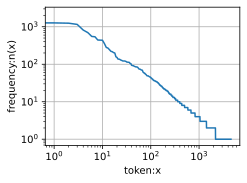

In [13]:
# 词频图
freqs = [freq for _, freq in vocab.token_freqs]
d2l.plot(freqs, xlabel='token:x', ylabel='frequency:n(x)',xscale='log', yscale='log')

In [14]:
# 其他词元组合：二元语法，三元语法
bigram_tokens = [pair for pair in zip(corpus[:-1], corpus[1:])]
bigram_vocab = d2l.Vocab(bigram_tokens)
bigram_vocab.token_freqs[:10]

[(('of', 'the'), 309),
 (('in', 'the'), 169),
 (('i', 'had'), 130),
 (('i', 'was'), 112),
 (('and', 'the'), 109),
 (('the', 'time'), 102),
 (('it', 'was'), 99),
 (('to', 'the'), 85),
 (('as', 'i'), 78),
 (('of', 'a'), 73)]

In [15]:
trigram_tokens = [triple for triple in zip(corpus[:-2], corpus[1:-1], corpus[2:])]
trigram_vocab = d2l.Vocab(trigram_tokens)
trigram_vocab.token_freqs[:10]

[(('the', 'time', 'traveller'), 59),
 (('the', 'time', 'machine'), 30),
 (('the', 'medical', 'man'), 24),
 (('it', 'seemed', 'to'), 16),
 (('it', 'was', 'a'), 15),
 (('here', 'and', 'there'), 15),
 (('seemed', 'to', 'me'), 14),
 (('i', 'did', 'not'), 14),
 (('i', 'saw', 'the'), 13),
 (('i', 'began', 'to'), 13)]

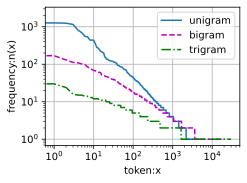

In [16]:
bigram_freqs = [freq for _, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for _, freq in trigram_vocab.token_freqs]
d2l.plot([freqs, bigram_freqs, trigram_freqs], xlabel='token:x', ylabel='frequency:n(x)',xscale='log', yscale='log', legend=['unigram', 'bigram', 'trigram'])


###### 训练语言模型时会遇到一个常见的问题：就是文本量太大，没法一次性输入模型，该怎么切成小块？我们希望将其拆分成固定长度的序列，根据目前的神经网络模型来看，我们会预定义一个长度为batch_size的序列，目前的问题就在于如何随机生成这样的小批量序列已经对应特征以便读取。<br>文本序列可以是任意长的，于是为了处理这种任意长的序列我们考虑将其划分为具有相同时间步数（也就是$\tau$）的子序列。而切分的起始位置不同会导致不同的子序列，所以我们可以选择任意偏移量来指示初始位置， 以此获得相当大的自由度。如下图所示：
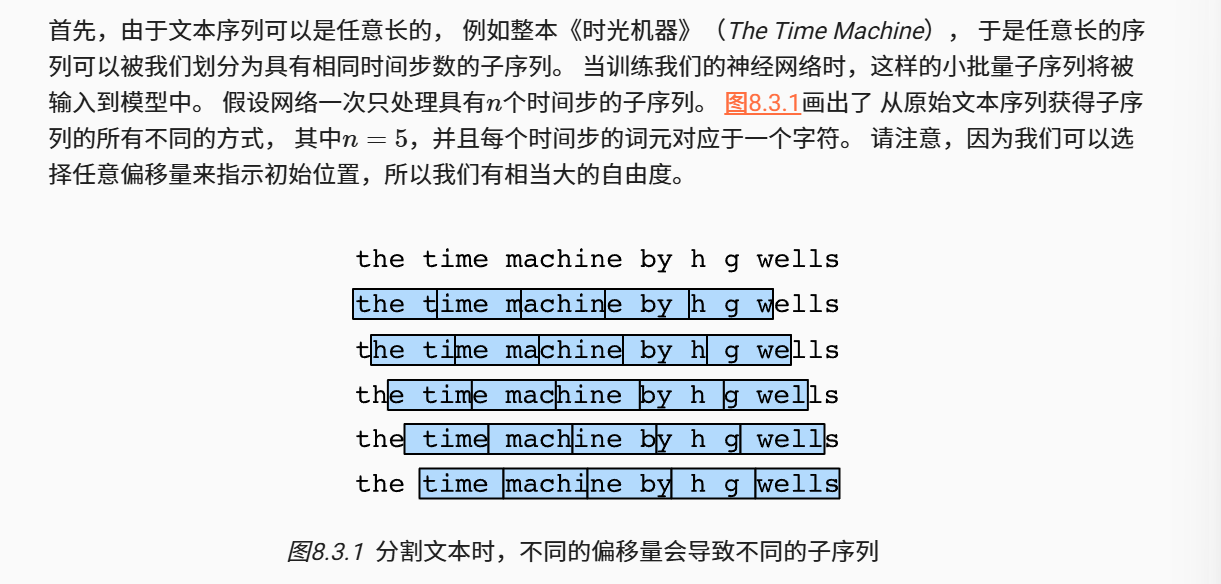
###### 所以我们该选择什么偏移量？事实上，都无所谓，它们都一样好。但是如果我们只选择一个偏移量，那么训练网络的子序列的覆盖范围将是有限的，也就说子序列的排列永远是固定的，模型能永远看到[A, B, C]，而不能看到[B, C, A]。所以我们采用随机偏移量来划分序列，以保证同时获得覆盖性和随机性。

In [17]:
# 随机采样，是在原始序列上任意捕获的子序列。
def seq_data_iter_random(corpus, batch_size, num_steps): #@save
    """使用随机采样生成一个小批量子序列"""
    # 从随机偏移量开始对序列进行分区，随机范围包括0-(num_steps-1)
    corpus = corpus[random.randint(0, num_steps - 1):]

    # 减去1，因为我们要考虑标签
    num_subseqs = (len(corpus) - 1 ) // num_steps # 计算可以生成的子序列数量

    # 计算每个子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))

    # 将索引随机打乱，也就意味着随机采样了子序列
    random.shuffle(initial_indices)

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的子序列
        return corpus[pos:pos + num_steps]
    
    num_batches = num_subseqs // batch_size # 计算可以生成的小批量数量
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引，获取小批量的起始索引
        initial_indices_per_batch = initial_indices[i:i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)


In [18]:
my_seq = list(range(35))
for X, Y in seq_data_iter_random(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY: ', Y)

X:  tensor([[26, 27, 28, 29, 30],
        [11, 12, 13, 14, 15]]) 
Y:  tensor([[27, 28, 29, 30, 31],
        [12, 13, 14, 15, 16]])
X:  tensor([[ 1,  2,  3,  4,  5],
        [21, 22, 23, 24, 25]]) 
Y:  tensor([[ 2,  3,  4,  5,  6],
        [22, 23, 24, 25, 26]])
X:  tensor([[ 6,  7,  8,  9, 10],
        [16, 17, 18, 19, 20]]) 
Y:  tensor([[ 7,  8,  9, 10, 11],
        [17, 18, 19, 20, 21]])


In [26]:
# 顺序分区
def seq_data_iter_sequential(corpus, batch_size, num_steps): #@save
    """使用顺序分区生成一个小批量子序列"""
    # 从随机偏移量开始划分序列
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + num_tokens + 1])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i:i + num_steps]
        Y = Ys[:, i:i + num_steps]
        yield X, Y

In [27]:
for X, Y in seq_data_iter_sequential(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY: ', Y)

X:  tensor([[ 5,  6,  7,  8,  9],
        [19, 20, 21, 22, 23]]) 
Y:  tensor([[ 6,  7,  8,  9, 10],
        [20, 21, 22, 23, 24]])
X:  tensor([[10, 11, 12, 13, 14],
        [24, 25, 26, 27, 28]]) 
Y:  tensor([[11, 12, 13, 14, 15],
        [25, 26, 27, 28, 29]])


In [ ]:
class SeqDataLoader: #@save
    """序列数据加载器"""
    def __init__(self, batch_size, num_steps, use_random_iter, max_tokens):
        if use_random_iter:
            self.data_iter_fn = d2l.seq_data_iter_random
        else:
            self.data_iter_fn = d2l.seq_data_iter_sequential
        self.corpus, self.vocab = d2l.load_corpus_time_machine(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps
    
    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)

In [ ]:
def load_data_time_machine(batch_size, num_steps, use_random_iter=False, max_tokens=10000):
    """返回时光机器数据集的迭代器和词表"""
    data_iter = SeqDataLoader(batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab